**Датасет:** https://www.kaggle.com/datasets/arashnic/electricity-consumption

# Лабораторная работа №1. Дополнительное задание
## Прогнозирование временных рядов через сведение к регрессии
### Отчет по практическому заданию курса «Машинное обучение»

### 1) Введение. Краткое описание целей и задач работы

- **Цель работы:** освоить базовый пайплайн прогнозирования временного ряда, сведя его к задаче регрессии: признаки только из прошлого, разделение по времени, кросс-валидация для рядов, одношаговый прогноз и прогноз на горизонт \(H\).
- **Постановка задачи:**
  1. Загрузить суточный ряд потребления электроэнергии в Германии (`data/opsd_germany_daily.csv`), привести дату к `datetime`, отсортировать и визуализировать ряд.
  2. Сделать вывод о тренде, сезонности и выбросах.
  3. Сформировать признаки без утечки из будущего: календарные, лаги, скользящие статистики, сезонные лаги.
  4. Разделить ряд по времени (train — ранние годы, test — 2017) и применить `TimeSeriesSplit`.
  5. Обучить Ridge-регрессию для прогноза на 1 шаг вперёд и реализовать **рекурсивную** стратегию на горизонт \(H = 14\) дней.
  6. Рассчитать MSE, MAE, MAPE, WAPE на train и test; сравнить с наивными базами; разобрать, где модель ошибается сильнее.
  7. Выполнить STL-декомпозицию и проверить, улучшают ли признаки на основе компонент качество прогноза.
- **Датасет:** суточное потребление электроэнергии в Германии, 2006–2017 годы. Целевая переменная — `Потребление` (ГВт·ч в сутки).


### 2) Описание датасета

Ряд публикуется проектом [Open Power System Data](https://data.open-power-system-data.org/) и доступен на [Kaggle](https://www.kaggle.com/datasets/arashnic/electricity-consumption). Файл содержит дату, суточное потребление электроэнергии в Германии и выработку ветра и солнца. Для прогноза используется только потребление: столбцы ветра и солнца в начале периода пустые, а их значения в тот же день были бы утечкой (это одновременные измерения, а не прошлое).


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import STL

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False

RU = {
    "Date": "Дата",
    "Consumption": "Потребление",
    "Wind": "Ветер",
    "Solar": "Солнце",
    "Wind+Solar": "Ветер+солнце",
}

raw = pd.read_csv("data/opsd_germany_daily.csv")
print("=" * 80)
print(f"Размерность датасета: {raw.shape[0]} строк, {raw.shape[1]} столбцов")
print("=" * 80)
print("\nПервые 5 строк:")
print(raw.rename(columns=RU).head().to_string())
print("\nТипы столбцов:")
print(raw.dtypes.to_string())
print("\nПропуски:")
print(raw.isnull().sum().to_string())
print(f"\nДубликатов строк: {int(raw.duplicated().sum())}")


Размерность датасета: 4383 строк, 5 столбцов

Первые 5 строк:
         Дата  Потребление  Ветер  Солнце  Ветер+солнце
0  2006-01-01     1069.184    NaN     NaN           NaN
1  2006-01-02     1380.521    NaN     NaN           NaN
2  2006-01-03     1442.533    NaN     NaN           NaN
3  2006-01-04     1457.217    NaN     NaN           NaN
4  2006-01-05     1477.131    NaN     NaN           NaN

Типы столбцов:
Date            object
Consumption    float64
Wind           float64
Solar          float64
Wind+Solar     float64

Пропуски:
Date              0
Consumption       0
Wind           1463
Solar          2195
Wind+Solar     2196

Дубликатов строк: 0


### Пояснение к первичному анализу

- **Объем:** 4383 суток, с 1 января 2006 по 31 декабря 2017. Пять столбцов: дата, потребление, ветер, солнце и их сумма.
- **Пропуски:** потребление полное. Ветер не заполнен в 1463 сутках (начало ряда, до 2010 года), солнце — в 2195 (до 2012-го). Именно поэтому в модель они не входят: на большей части истории их нет.
- **Дубликатов** нет.
- **Целевая переменная** — суточное потребление электроэнергии в ГВт·ч. Это непрерывный числовой ряд, зависящий от времени, календаря и режима экономики.


In [2]:
df = raw.copy()
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").set_index("Date")
y = df["Consumption"].asfreq("D")

print(f"Тип индекса: {df.index.dtype}")
print(f"Период: {y.index.min().date()} — {y.index.max().date()}")
print(f"Пропусков дат после asfreq('D'): {int(y.isna().sum())}")
print(f"Монотонность индекса: {bool(df.index.is_monotonic_increasing)}")

stats = y.describe().to_frame("Потребление, ГВт·ч")
stats.loc["Медиана"] = y.median()
stats.loc["Асимметрия"] = y.skew()
print("\nОписательная статистика целевого ряда:")
print(stats.round(2).to_string())


Тип индекса: datetime64[ns]
Период: 2006-01-01 — 2017-12-31
Пропусков дат после asfreq('D'): 0
Монотонность индекса: True

Описательная статистика целевого ряда:
            Потребление, ГВт·ч
count                  4383.00
mean                   1338.68
std                     165.78
min                     842.40
25%                    1217.86
50%                    1367.12
75%                    1457.76
max                    1709.57
Медиана                1367.12
Асимметрия               -0.43


### Пояснение к приведению дат

Столбец `Date` приведён к `datetime64`, ряд отсортирован по времени и зафиксирован с частотой сутки (`asfreq("D")`). Пропущенных календарных дней нет: ряд сплошной. Среднее потребление 1338,7 ГВт·ч, медиана 1367,1, размах 842,4–1709,6, асимметрия −0,43. Это типичный суточный профиль крупной энергосистемы: унимодальный ряд без дыр в календаре.


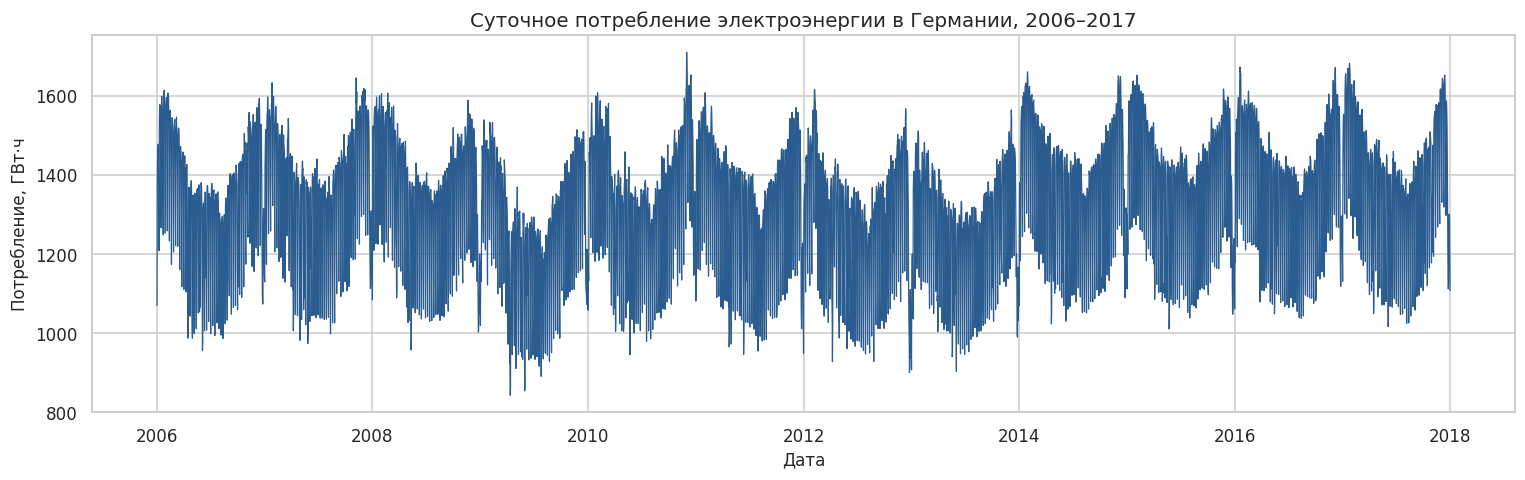

In [3]:
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(y.index, y.values, color="#2b5c8f", linewidth=0.8)
ax.set_title("Суточное потребление электроэнергии в Германии, 2006–2017")
ax.set_xlabel("Дата")
ax.set_ylabel("Потребление, ГВт·ч")
plt.tight_layout()
plt.show()


### Вывод по графику ряда

- **Тренд:** слабый, почти плоский на горизонте 12 лет. Уровень потребления колеблется вокруг 1200–1500 ГВт·ч, без резкого долгосрочного роста или спада.
- **Сезонность:** хорошо видна **годовая** — зима выше лета (отопление, короткий день, промышленный календарь). Внутри года повторяется пила рабочей недели.
- **Выбросы:** отдельные провалы в конце декабря — рождественские каникулы, когда промышленность и офисы останавливаются. Это не ошибки измерения, а календарные аномалии.


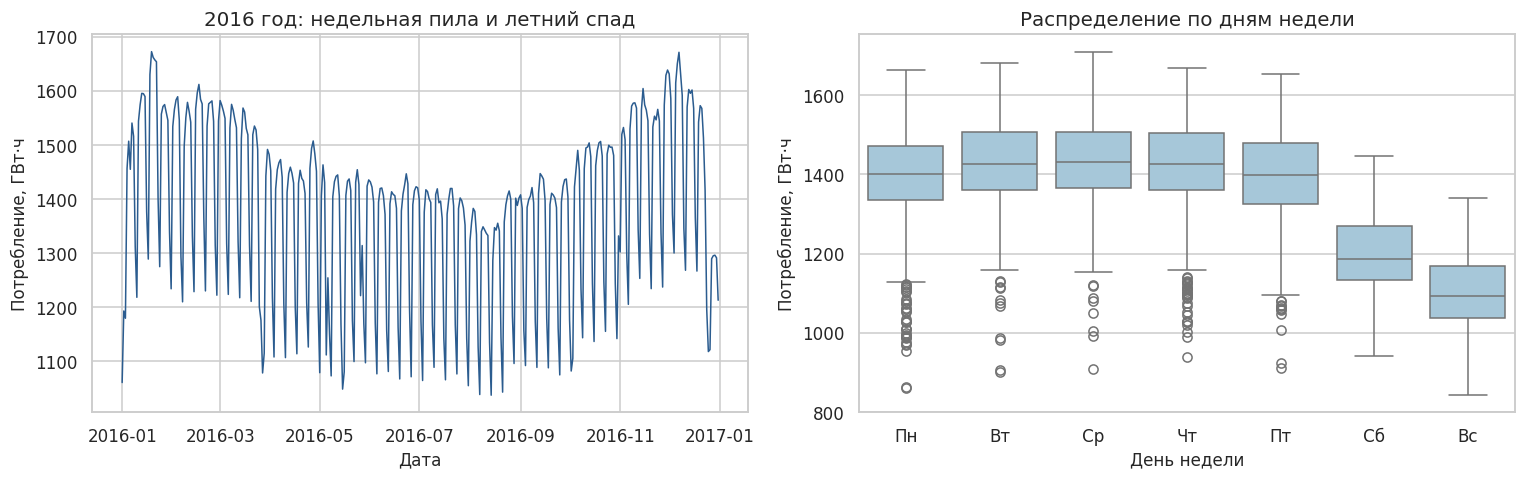

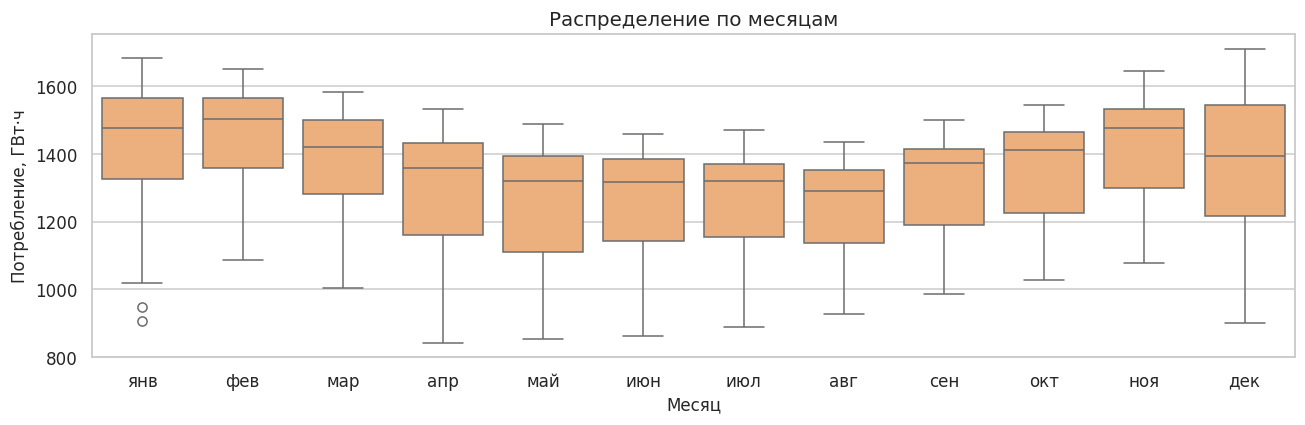

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

y_2016 = y.loc["2016"]
axes[0].plot(y_2016.index, y_2016.values, color="#2b5c8f", linewidth=1)
axes[0].set_title("2016 год: недельная пила и летний спад")
axes[0].set_xlabel("Дата")
axes[0].set_ylabel("Потребление, ГВт·ч")

dow_ru = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]
tmp = pd.DataFrame({"y": y, "dow": y.index.dayofweek, "month": y.index.month})
sns.boxplot(data=tmp, x="dow", y="y", ax=axes[1], color="#9ecae1")
axes[1].set_xticklabels(dow_ru)
axes[1].set_title("Распределение по дням недели")
axes[1].set_xlabel("День недели")
axes[1].set_ylabel("Потребление, ГВт·ч")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
sns.boxplot(data=tmp, x="month", y="y", ax=ax, color="#fdae6b")
ax.set_xticklabels(["янв", "фев", "мар", "апр", "май", "июн",
                    "июл", "авг", "сен", "окт", "ноя", "дек"])
ax.set_title("Распределение по месяцам")
ax.set_xlabel("Месяц")
ax.set_ylabel("Потребление, ГВт·ч")
plt.tight_layout()
plt.show()


### Сезонность подробнее

- **Недельная:** будни заметно выше выходных. Суббота ниже пятницы, воскресенье — самый низкий день: промышленная нагрузка падает в выходные.
- **Годовая:** январь–февраль и ноябрь–декабрь — максимум, июль–август — минимум (отпуска, нет отопления).
- **Суточной** сезонности в файле нет: наблюдения дневные, часа нет.
- На графике 2016 года видна регулярная недельная пила и провал на Рождество. Для регрессии это означает: нужны день недели, выходной, праздник, лаг 7 и лаг 365.


### 3) Подготовка данных. Признаки только из прошлого

Все лаги и окна считаются по уже известным значениям ряда: сначала сдвиг на 1 шаг, затем скользящее окно. Календарные поля берутся из даты прогноза — они известны заранее. Ветер и солнце не используются.


In [5]:
EASTER_MONDAY = {
    2006: (4, 17), 2007: (4, 9), 2008: (3, 24), 2009: (4, 13),
    2010: (4, 5), 2011: (4, 25), 2012: (4, 9), 2013: (4, 1),
    2014: (4, 21), 2015: (4, 6), 2016: (3, 28), 2017: (4, 17),
}
FIXED_HOLIDAYS = {(1, 1), (5, 1), (10, 3), (12, 24), (12, 25), (12, 26), (12, 31)}


def is_german_holiday(d):
    md = (d.month, d.day)
    em = EASTER_MONDAY.get(d.year)
    return int(md in FIXED_HOLIDAYS or (em is not None and md == em))


feat = pd.DataFrame({"y": y})
feat["День недели"] = feat.index.dayofweek
feat["Месяц"] = feat.index.month
feat["Год"] = feat.index.year
feat["Выходной"] = (feat["День недели"] >= 5).astype(int)
feat["Праздник"] = [is_german_holiday(d) for d in feat.index]

for p in [1, 2, 3, 7, 14, 365]:
    feat[f"Лаг {p}"] = feat["y"].shift(p)

for w in [7, 30]:
    rolled = feat["y"].shift(1).rolling(w)
    feat[f"Ср. {w} дн."] = rolled.mean()
    feat[f"Мед. {w} дн."] = rolled.median()
    feat[f"СКО {w} дн."] = rolled.std()
    feat[f"Мин. {w} дн."] = rolled.min()
    feat[f"Макс. {w} дн."] = rolled.max()

print("Пропуски после сдвигов (первые 365 дней из-за годового лага):")
print(feat.isna().sum().to_string())
feat = feat.dropna()
print(f"\nПосле удаления неполных строк: {feat.shape[0]} наблюдений, {feat.shape[1] - 1} признаков")
print(f"Период признаков: {feat.index.min().date()} — {feat.index.max().date()}")
print("\nФрагмент матрицы признаков:")
print(feat.head(3).round(2).to_string())


Пропуски после сдвигов (первые 365 дней из-за годового лага):
y                 0
День недели       0
Месяц             0
Год               0
Выходной          0
Праздник          0
Лаг 1             1
Лаг 2             2
Лаг 3             3
Лаг 7             7
Лаг 14           14
Лаг 365         365
Ср. 7 дн.         7
Мед. 7 дн.        7
СКО 7 дн.         7
Мин. 7 дн.        7
Макс. 7 дн.       7
Ср. 30 дн.       30
Мед. 30 дн.      30
СКО 30 дн.       30
Мин. 30 дн.      30
Макс. 30 дн.     30

После удаления неполных строк: 4018 наблюдений, 21 признаков
Период признаков: 2007-01-01 — 2017-12-31

Фрагмент матрицы признаков:
                  y  День недели  Месяц   Год  Выходной  Праздник    Лаг 1    Лаг 2    Лаг 3    Лаг 7   Лаг 14  Лаг 365  Ср. 7 дн.  Мед. 7 дн.  СКО 7 дн.  Мин. 7 дн.  Макс. 7 дн.  Ср. 30 дн.  Мед. 30 дн.  СКО 30 дн.  Мин. 30 дн.  Макс. 30 дн.
Date                                                                                                                      

### Пояснение к признакам

| Группа | Что входит | Зачем |
| --- | --- | --- |
| Календарь | день недели, месяц, год, выходной, праздник | недельный и годовой режим нагрузки, каникулы |
| Лаги | \(y_{t-1}, y_{t-2}, y_{t-3}, y_{t-7}, y_{t-14}, y_{t-365}\) | инерция, прошлая неделя и тот же день год назад |
| Скользящие | среднее, медиана, СКО, min, max за 7 и 30 дней по \(y_{t-1}\) | локальный уровень и размах **без текущего дня** |

Утечки нет: `shift(1)` стоит перед `rolling`, годовой лаг берёт только прошлый год. Первые 365 дней отбрасываются — иначе в матрице были бы пустые лаги.


Train: 3653 суток, 2007-01-01 — 2016-12-31
Test:  365 суток, 2017-01-01 — 2017-12-31
Перемешивания нет: граница — календарный Новый год 2017.


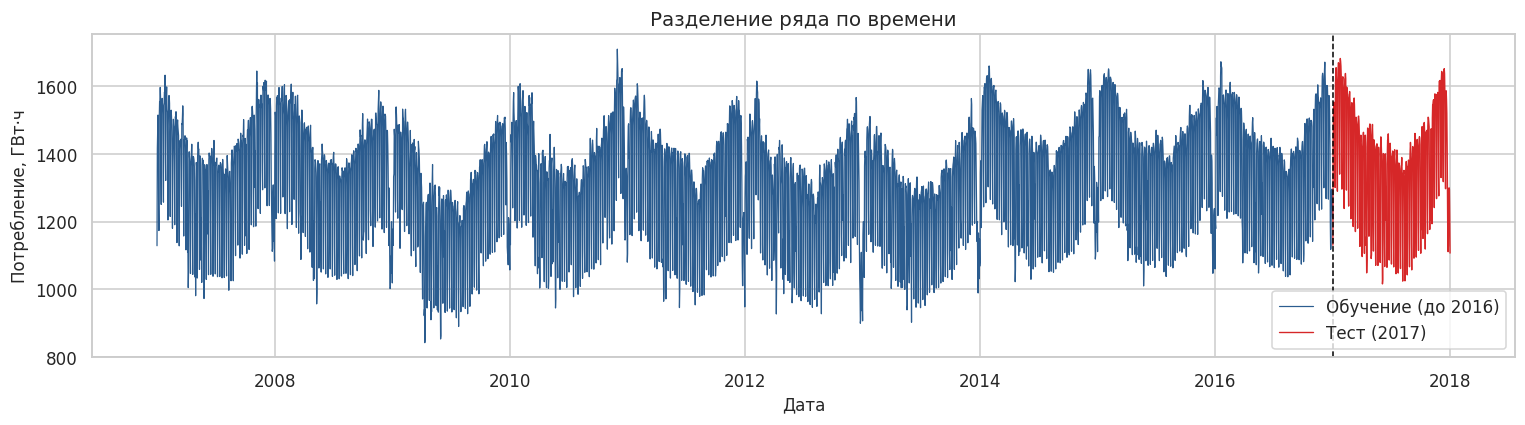

In [6]:
train = feat.loc[:"2016-12-31"]
test = feat.loc["2017-01-01":]
X_cols = [c for c in feat.columns if c != "y"]

print(f"Train: {len(train)} суток, {train.index.min().date()} — {train.index.max().date()}")
print(f"Test:  {len(test)} суток, {test.index.min().date()} — {test.index.max().date()}")
print("Перемешивания нет: граница — календарный Новый год 2017.")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train.index, train["y"], color="#2b5c8f", linewidth=0.8, label="Обучение (до 2016)")
ax.plot(test.index, test["y"], color="#d62728", linewidth=0.9, label="Тест (2017)")
ax.axvline(pd.Timestamp("2017-01-01"), color="black", linestyle="--", linewidth=1)
ax.set_title("Разделение ряда по времени")
ax.set_xlabel("Дата")
ax.set_ylabel("Потребление, ГВт·ч")
ax.legend()
plt.tight_layout()
plt.show()


### Разделение выборки

Train — 2007–2016 (3653 дня после отбрасывания годового лага), test — весь 2017 год (365 дней). Последний год не участвует в подборе коэффициентов. Случайный `train_test_split` здесь недопустим: будущие сутки оказались бы в обучении, и лаги «из будущего» завысили бы качество.


### 4) Ход работы. Кросс-валидация и модель


In [7]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=10)),
])
tscv = TimeSeriesSplit(n_splits=5)

print("Схема TimeSeriesSplit (расширяющееся окно):")
for i, (tr_idx, val_idx) in enumerate(tscv.split(train), start=1):
    tr, va = train.iloc[tr_idx], train.iloc[val_idx]
    print(
        f"  Фолд {i}: train {tr.index.min().date()}…{tr.index.max().date()} "
        f"({len(tr)} дн.) | val {va.index.min().date()}…{va.index.max().date()} ({len(va)} дн.)"
    )

cv_mae = cross_val_score(
    pipe, train[X_cols], train["y"], cv=tscv, scoring="neg_mean_absolute_error"
)
cv_rmse = cross_val_score(
    pipe, train[X_cols], train["y"], cv=tscv, scoring="neg_root_mean_squared_error"
)
print(f"\nCV MAE:  {-cv_mae.mean():.2f} ± {cv_mae.std():.2f} ГВт·ч")
print(f"CV RMSE: {-cv_rmse.mean():.2f} ± {cv_rmse.std():.2f} ГВт·ч")


Схема TimeSeriesSplit (расширяющееся окно):
  Фолд 1: train 2007-01-01…2008-09-04 (613 дн.) | val 2008-09-05…2010-05-05 (608 дн.)
  Фолд 2: train 2007-01-01…2010-05-05 (1221 дн.) | val 2010-05-06…2012-01-03 (608 дн.)
  Фолд 3: train 2007-01-01…2012-01-03 (1829 дн.) | val 2012-01-04…2013-09-02 (608 дн.)
  Фолд 4: train 2007-01-01…2013-09-02 (2437 дн.) | val 2013-09-03…2015-05-03 (608 дн.)
  Фолд 5: train 2007-01-01…2015-05-03 (3045 дн.) | val 2015-05-04…2016-12-31 (608 дн.)

CV MAE:  29.26 ± 2.88 ГВт·ч
CV RMSE: 48.18 ± 3.95 ГВт·ч


### Пояснение к кросс-валидации

`TimeSeriesSplit` с 5 фолдами строит **расширяющееся окно**: каждый следующий фолд добавляет более поздние годы в обучение и проверяет на следующем блоке. Перемешивания нет, валидация всегда позже обучения. Ridge со стандартизацией выбран как устойчивая линейная модель: лаги и скользящие статистики сильно коррелируют, обычный МНК раздул бы коэффициенты.


In [8]:
def metrics_table(y_true, y_pred, name):
    yt, yp = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    mse = mean_squared_error(yt, yp)
    mae = mean_absolute_error(yt, yp)
    mape = mean_absolute_percentage_error(yt, yp) * 100
    wape = np.sum(np.abs(yt - yp)) / np.sum(np.abs(yt)) * 100
    return pd.Series({"MSE": mse, "MAE": mae, "MAPE, %": mape, "WAPE, %": wape}, name=name)


pipe.fit(train[X_cols], train["y"])
pred_train = pipe.predict(train[X_cols])
pred_test = pipe.predict(test[X_cols])

one_step = pd.concat([
    metrics_table(train["y"], pred_train, "Ridge, train, 1 шаг"),
    metrics_table(test["y"], pred_test, "Ridge, test, 1 шаг"),
    metrics_table(test["y"], test["Лаг 1"], "Наивный лаг 1, test"),
    metrics_table(test["y"], test["Лаг 7"], "Наивный лаг 7, test"),
    metrics_table(test["y"], test["Лаг 365"], "Наивный лаг 365, test"),
], axis=1).T

print("Одношаговый прогноз (лаги на тесте — фактические прошлые значения):")
print(one_step.round(3).to_string())


Одношаговый прогноз (лаги на тесте — фактические прошлые значения):
                             MSE      MAE  MAPE, %  WAPE, %
Ridge, train, 1 шаг     2115.634   28.051    2.212    2.103
Ridge, test, 1 шаг      2199.737   27.354    2.094    1.978
Наивный лаг 1, test    22248.041  102.337    7.729    7.400
Наивный лаг 7, test     9350.761   54.104    4.042    3.913
Наивный лаг 365, test  23011.856  105.047    7.879    7.596


### Оценка одношагового прогноза

На тесте 2017 года Ridge даёт MAE **27,35 ГВт·ч**, MAPE **2,09%**, WAPE **1,98%**. Это заметно лучше наивных баз: вчерашний день (лаг 1) ошибается на 102,3 ГВт·ч, тот же день год назад — на 105,0, прошлый тот же день недели (лаг 7) — на 54,1. Train и test близки (MAE 28,05 и 27,35), кросс-валидация даёт MAE 29,26 ± 2,88. Переобучения по метрикам нет: модель обобщает на следующий год.

Одношаговый тест использует **фактические** лаги: к моменту прогноза на завтра вчерашнее потребление уже известно. Это честная схема оперативного прогноза на 1 сутки, но не схема прогноза на две недели вперёд.


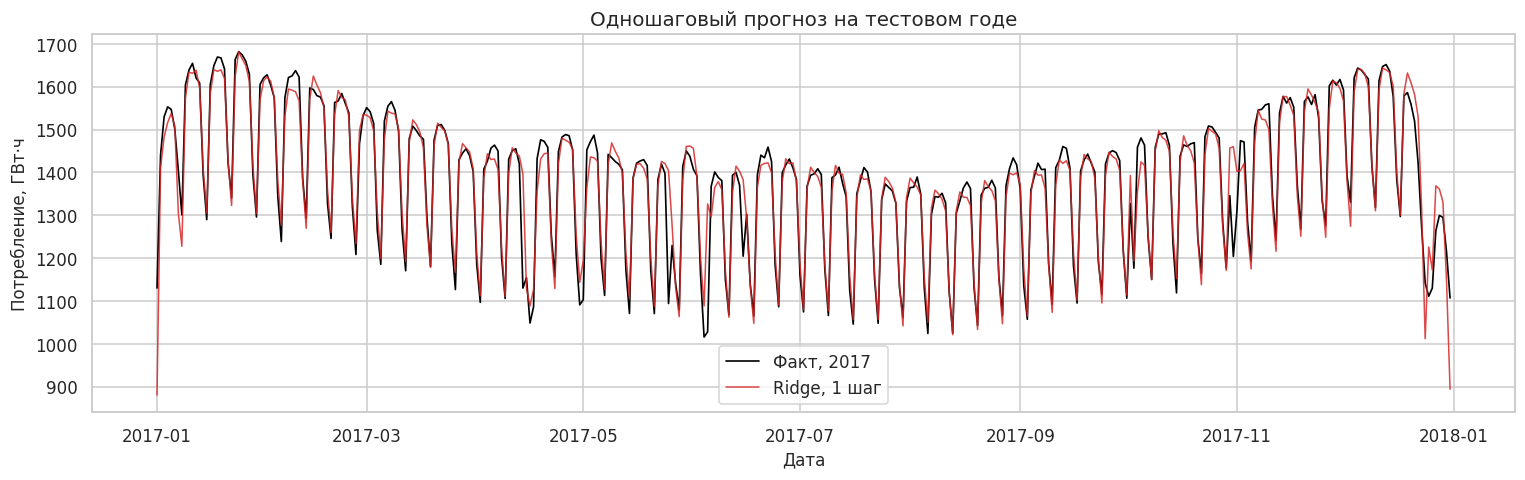

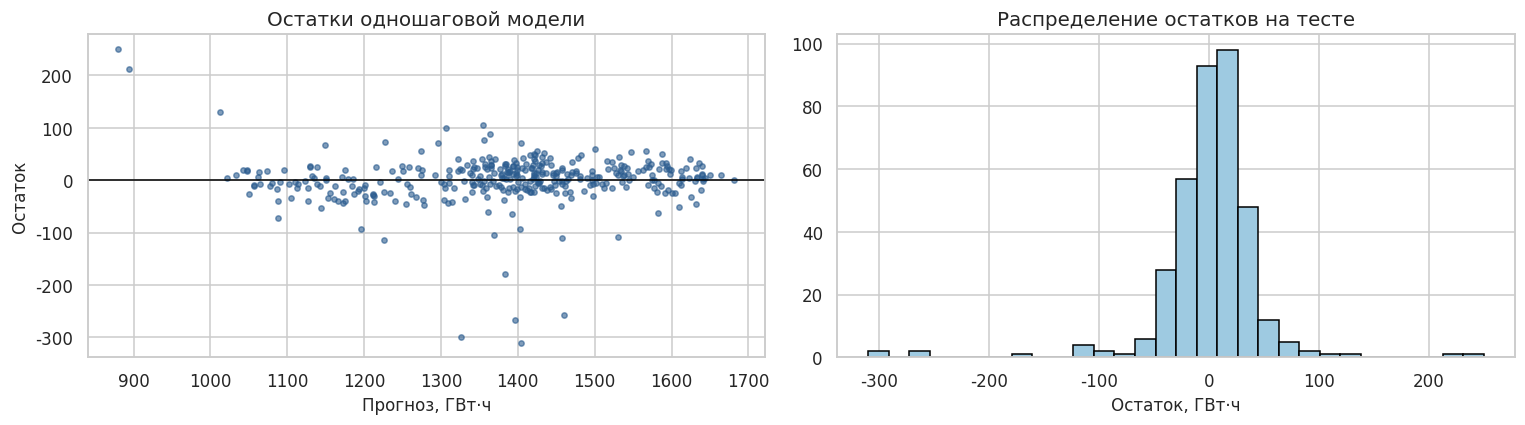

In [9]:
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(test.index, test["y"], color="black", linewidth=1.1, label="Факт, 2017")
ax.plot(test.index, pred_test, color="#d62728", linewidth=1, alpha=0.85, label="Ridge, 1 шаг")
ax.set_title("Одношаговый прогноз на тестовом годе")
ax.set_xlabel("Дата")
ax.set_ylabel("Потребление, ГВт·ч")
ax.legend()
plt.tight_layout()
plt.show()

resid = test["y"].values - pred_test
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].scatter(pred_test, resid, s=12, alpha=0.6, color="#2b5c8f")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_xlabel("Прогноз, ГВт·ч")
axes[0].set_ylabel("Остаток")
axes[0].set_title("Остатки одношаговой модели")
axes[1].hist(resid, bins=30, color="#9ecae1", edgecolor="black")
axes[1].set_title("Распределение остатков на тесте")
axes[1].set_xlabel("Остаток, ГВт·ч")
plt.tight_layout()
plt.show()


### Пояснение к графику одношагового прогноза

Красная линия почти совпадает с фактом на обычных неделях: модель воспроизводит рабочую пилу. Расхождения видны в декабре и на отдельных праздниках — там остатки уходят за 100 ГВт·ч. Облако остатков центрировано около нуля, без явного «веера» по уровню прогноза: линейной модели хватает на будний режим.


MAE по дням недели, ГВт·ч:
Пн    34.6
Вт    22.8
Ср    23.6
Чт    30.5
Пт    26.7
Сб    23.2
Вс    30.1

MAE по месяцам, ГВт·ч:
янв    31.0
фев    22.5
мар    15.9
апр    33.8
май    36.3
июн    38.3
июл    14.1
авг    17.4
сен    16.9
окт    32.8
ноя    26.2
дек    42.8

MAE в праздники: 112.4
MAE в обычные дни: 25.4
MAE в выходные: 26.7
MAE в будни: 27.6


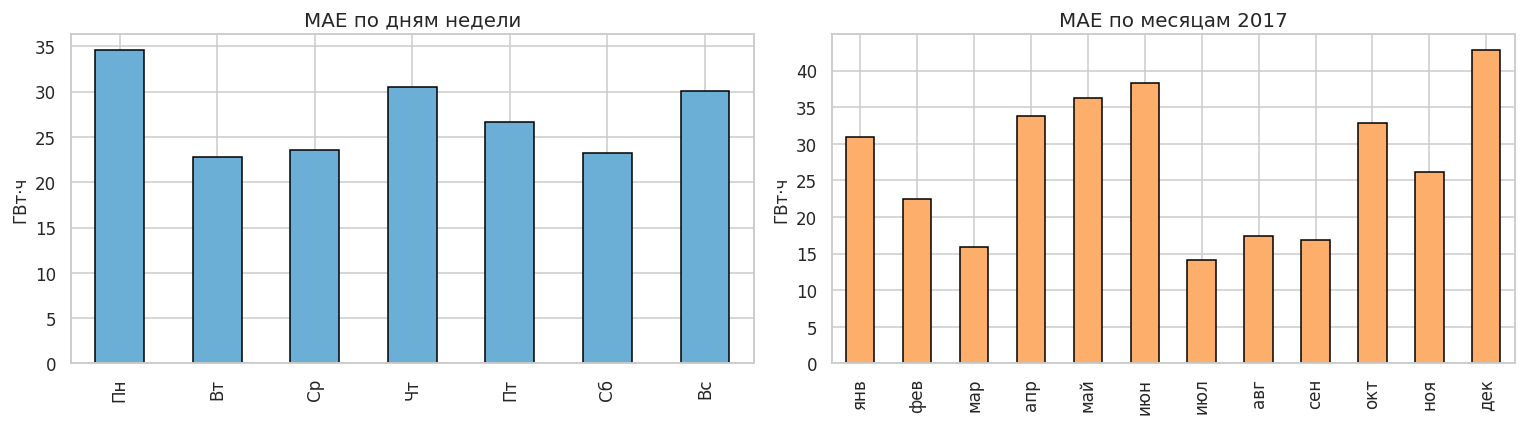

In [10]:
err = pd.Series(np.abs(test["y"].values - pred_test), index=test.index, name="MAE")
by_dow = err.groupby(test.index.dayofweek).mean()
by_dow.index = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]
by_month = err.groupby(test.index.month).mean()
by_month.index = ["янв", "фев", "мар", "апр", "май", "июн", "июл", "авг", "сен", "окт", "ноя", "дек"]

print("MAE по дням недели, ГВт·ч:")
print(by_dow.round(1).to_string())
print("\nMAE по месяцам, ГВт·ч:")
print(by_month.round(1).to_string())
print(f"\nMAE в праздники: {err[test['Праздник'] == 1].mean():.1f}")
print(f"MAE в обычные дни: {err[test['Праздник'] == 0].mean():.1f}")
print(f"MAE в выходные: {err[test['Выходной'] == 1].mean():.1f}")
print(f"MAE в будни: {err[test['Выходной'] == 0].mean():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
by_dow.plot(kind="bar", ax=axes[0], color="#6baed6", edgecolor="black")
axes[0].set_title("MAE по дням недели")
axes[0].set_ylabel("ГВт·ч")
by_month.plot(kind="bar", ax=axes[1], color="#fdae6b", edgecolor="black")
axes[1].set_title("MAE по месяцам 2017")
axes[1].set_ylabel("ГВт·ч")
plt.tight_layout()
plt.show()


### Где модель ошибается сильнее

- **Праздники:** MAE 112,4 ГВт·ч против 25,4 в обычные дни. Фиксированного флага праздника мало: Рождество, пасхальный понедельник и «мосты» между праздником и выходным снижают нагрузку сильнее, чем средний праздник в обучении.
- **Декабрь** — худший месяц (MAE 42,8): каникулы растянуты, промышленность стоит несколько дней подряд. Лучшие месяцы — март и июль (15,9 и 14,1).
- **Понедельник** чуть хуже остальных будней (34,6; переход с выходного). **Тренд** как таковой модель почти не ломает — уровня ряда за 2017 год линейной комбинации лагов хватает. Основной источник ошибки — **календарные выбросы**, а не недельная сезонность.


Рекурсивный прогноз на H = 14 суток с 2017-01-01 (лаги = собственные прогнозы):
                            MSE      MAE  MAPE, %  WAPE, %
Ridge, рекурсия H=14  88887.887  295.771   19.945   19.784

Наивный прогноз «последнее известное значение»:
                        MSE     MAE  MAPE, %  WAPE, %
Наивный уровень  100228.666  294.18   19.078   19.677


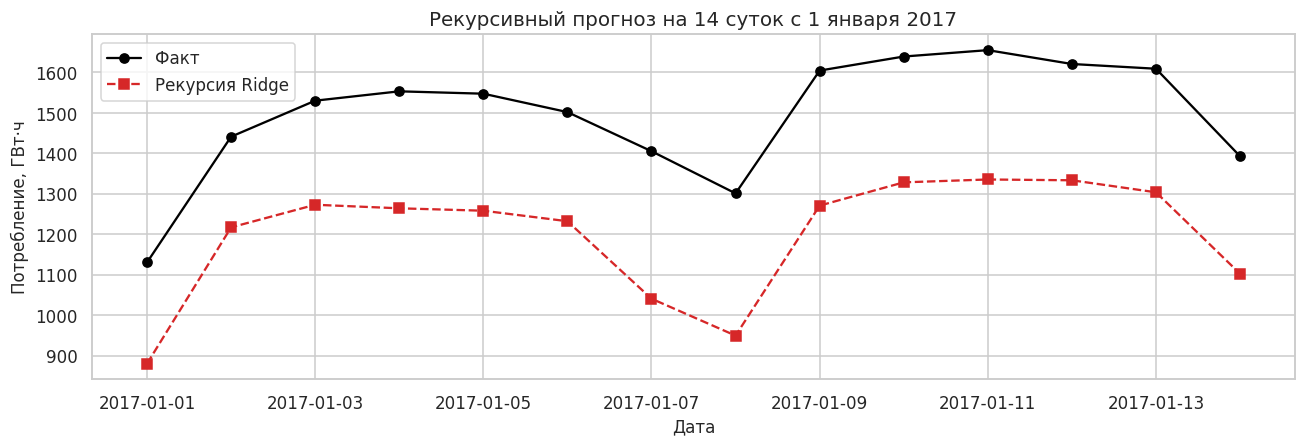

In [11]:
def recursive_forecast(model, history, dates, x_cols):
    hist = list(history)
    preds = []
    for d in dates:
        row = {
            "День недели": d.dayofweek,
            "Месяц": d.month,
            "Год": d.year,
            "Выходной": int(d.dayofweek >= 5),
            "Праздник": is_german_holiday(d),
            "Лаг 1": hist[-1],
            "Лаг 2": hist[-2],
            "Лаг 3": hist[-3],
            "Лаг 7": hist[-7],
            "Лаг 14": hist[-14],
            "Лаг 365": hist[-365],
        }
        for w in [7, 30]:
            wdw = np.asarray(hist[-w:], dtype=float)
            row[f"Ср. {w} дн."] = wdw.mean()
            row[f"Мед. {w} дн."] = np.median(wdw)
            row[f"СКО {w} дн."] = wdw.std(ddof=1)
            row[f"Мин. {w} дн."] = wdw.min()
            row[f"Макс. {w} дн."] = wdw.max()
        yhat = float(model.predict(pd.DataFrame([row])[x_cols])[0])
        preds.append(yhat)
        hist.append(yhat)
    return np.asarray(preds)


H = 14
origin = pd.Timestamp("2017-01-01")
dates_h = pd.date_range(origin, periods=H, freq="D")
history = feat.loc[: origin - pd.Timedelta(days=1), "y"]
rec_preds = recursive_forecast(pipe, history.values, dates_h, X_cols)
actual_h = y.loc[dates_h]

print(f"Рекурсивный прогноз на H = {H} суток с {origin.date()} (лаги = собственные прогнозы):")
print(metrics_table(actual_h, rec_preds, "Ridge, рекурсия H=14").to_frame().T.round(3).to_string())
print("\nНаивный прогноз «последнее известное значение»:")
print(metrics_table(actual_h, np.repeat(history.iloc[-1], H), "Наивный уровень").to_frame().T.round(3).to_string())

fig, ax = plt.subplots(figsize=(12, 4.2))
ax.plot(dates_h, actual_h.values, "o-", color="black", label="Факт")
ax.plot(dates_h, rec_preds, "s--", color="#d62728", label="Рекурсия Ridge")
ax.set_title("Рекурсивный прогноз на 14 суток с 1 января 2017")
ax.set_xlabel("Дата")
ax.set_ylabel("Потребление, ГВт·ч")
ax.legend()
plt.tight_layout()
plt.show()


### Рекурсивная стратегия на горизонт \(H = 14\)

На каждом следующем шаге модель подставляет **свой вчерашний прогноз** вместо фактического лага. Ошибка накапливается. Старт с 1 января — худший случай: MAE 295,8 ГВт·ч, почти как наивный уровень (294,2). Первые дни горизонта — новогодние каникулы, искажённые лаги дальше тащат всю траекторию. Одношаговая модель здесь не «ломается», ломается схема: она училась на фактических лагах, а в рекурсии получает собственные ошибки.


In [12]:
all_y = feat["y"]
origins = test.index[::14]
rows = []
rec_all, act_all = [], []
for origin in origins:
    end = origin + pd.Timedelta(days=H - 1)
    if end > test.index.max():
        break
    hist = all_y.loc[: origin - pd.Timedelta(days=1)]
    dates = pd.date_range(origin, periods=H, freq="D")
    preds = recursive_forecast(pipe, hist.values, dates, X_cols)
    act = all_y.loc[dates].values
    rec_all.extend(preds)
    act_all.extend(act)
    rows.append({
        "Старт": origin.date(),
        **metrics_table(act, preds, "tmp").to_dict(),
    })

roll = pd.DataFrame(rows)
print("Рекурсия H=14 по скользящим стартам внутри 2017 (шаг 14 дней):")
print(roll.round(2).to_string(index=False))
print("\nСводка по всем точкам горизонта:")
print(metrics_table(act_all, rec_all, "Ridge, рекурсия H=14, все старты").to_frame().T.round(3).to_string())


Рекурсия H=14 по скользящим стартам внутри 2017 (шаг 14 дней):
     Старт      MSE    MAE  MAPE, %  WAPE, %
2017-01-01 88887.89 295.77    19.94    19.78
2017-01-15  1735.60  37.19     2.33     2.37
2017-01-29   777.74  21.74     1.46     1.42
2017-02-12   368.37  16.01     1.10     1.07
2017-02-26  1113.90  25.96     1.92     1.80
2017-03-12   550.95  19.65     1.42     1.39
2017-03-26  2787.76  48.50     3.69     3.58
2017-04-09  8065.08  63.32     5.12     4.82
2017-04-23  2765.75  45.80     3.40     3.38
2017-05-07  1351.06  32.59     2.53     2.44
2017-05-21  9782.96  51.05     4.36     3.95
2017-06-04 14952.27  83.38     7.18     6.63
2017-06-18  2025.16  40.22     2.94     3.01
2017-07-02   496.44  17.76     1.39     1.36
2017-07-16   344.62  16.60     1.30     1.29
2017-07-30   483.46  19.54     1.55     1.54
2017-08-13  1115.55  28.12     2.17     2.20
2017-08-27  2025.00  39.68     2.94     3.01
2017-09-10  1721.46  38.01     2.77     2.83
2017-09-24  4498.64  54.80     3.97  

### Сводка по горизонту \(H\)

Если запускать рекурсию каждые две недели в течение 2017 года, средняя MAE на 14 шагах — **50,24 ГВт·ч** (MAPE 3,68%, WAPE 3,63%). Это хуже одношагового теста (27,35), но в обычные недели (февраль, июль, октябрь) MAE падает до 14–22 ГВт·ч. Всплески — 1 января (295,8), начало июня и конец декабря. Для оперативного прогноза на завтра одношаговая схема достаточна; для графика на две недели нужна либо прямая модель на каждый шаг, либо отдельный сезонный метод.


Коэффициенты Ridge после стандартизации (по модулю):
Выходной       -71.28
День недели    -63.67
Лаг 1           55.53
Мин. 7 дн.      43.13
Праздник       -31.37
Мин. 30 дн.     18.58
Мед. 7 дн.     -13.00
Мед. 30 дн.    -12.00
Лаг 2           11.84
Лаг 3           11.05
СКО 30 дн.      10.97
СКО 7 дн.       10.74
Ср. 7 дн.        8.45
Ср. 30 дн.       6.87
Лаг 14          -6.77
Лаг 365          3.54
Макс. 7 дн.     -3.31
Месяц            2.36
Лаг 7           -1.70
Макс. 30 дн.    -1.39
Год             -0.96


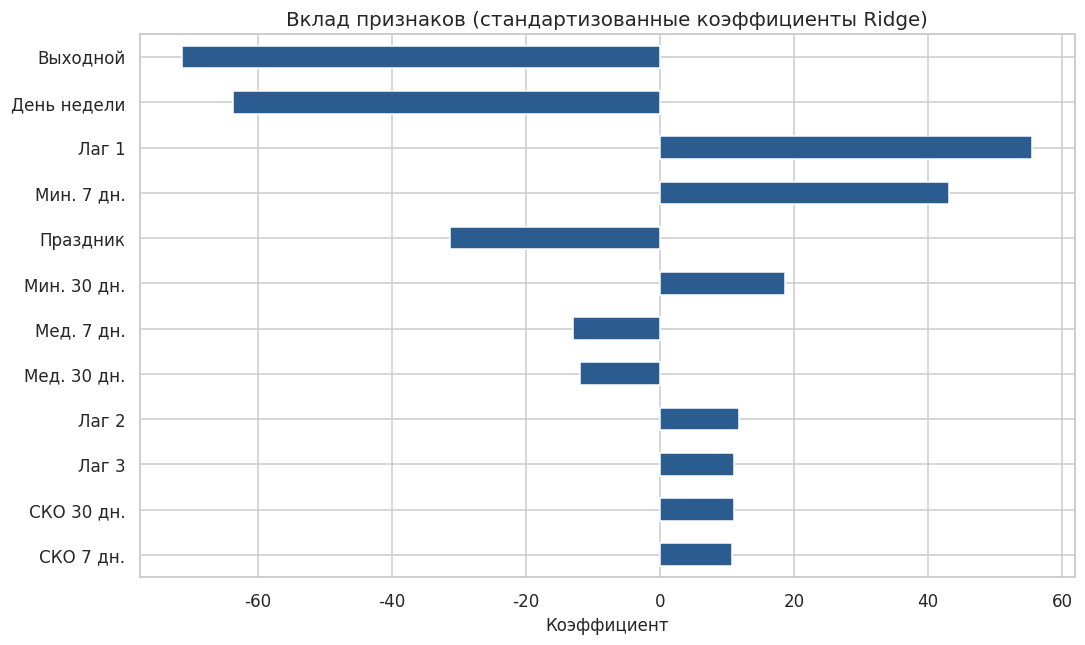

In [13]:
coef = pd.Series(pipe.named_steps["model"].coef_, index=X_cols).sort_values(key=np.abs, ascending=False)
print("Коэффициенты Ridge после стандартизации (по модулю):")
print(coef.round(2).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
coef.head(12).iloc[::-1].plot(kind="barh", ax=ax, color="#2b5c8f")
ax.set_title("Вклад признаков (стандартизованные коэффициенты Ridge)")
ax.set_xlabel("Коэффициент")
plt.tight_layout()
plt.show()


### Интерпретация коэффициентов

После стандартизации сильнее всего работают **выходной**, **день недели**, **лаг 1** и скользящий минимум за неделю. Это согласуется с графиком: уровень вчерашнего дня задаёт инерцию, календарь — форму недели. Годовой лаг слабее недельных признаков: сезонность уже частично сидит в месяце и в окне 30 дней. Знаки у скользящих min/max нужно читать осторожно — они коррелируют с лагами, Ridge только стабилизирует, но не делает их независимыми.


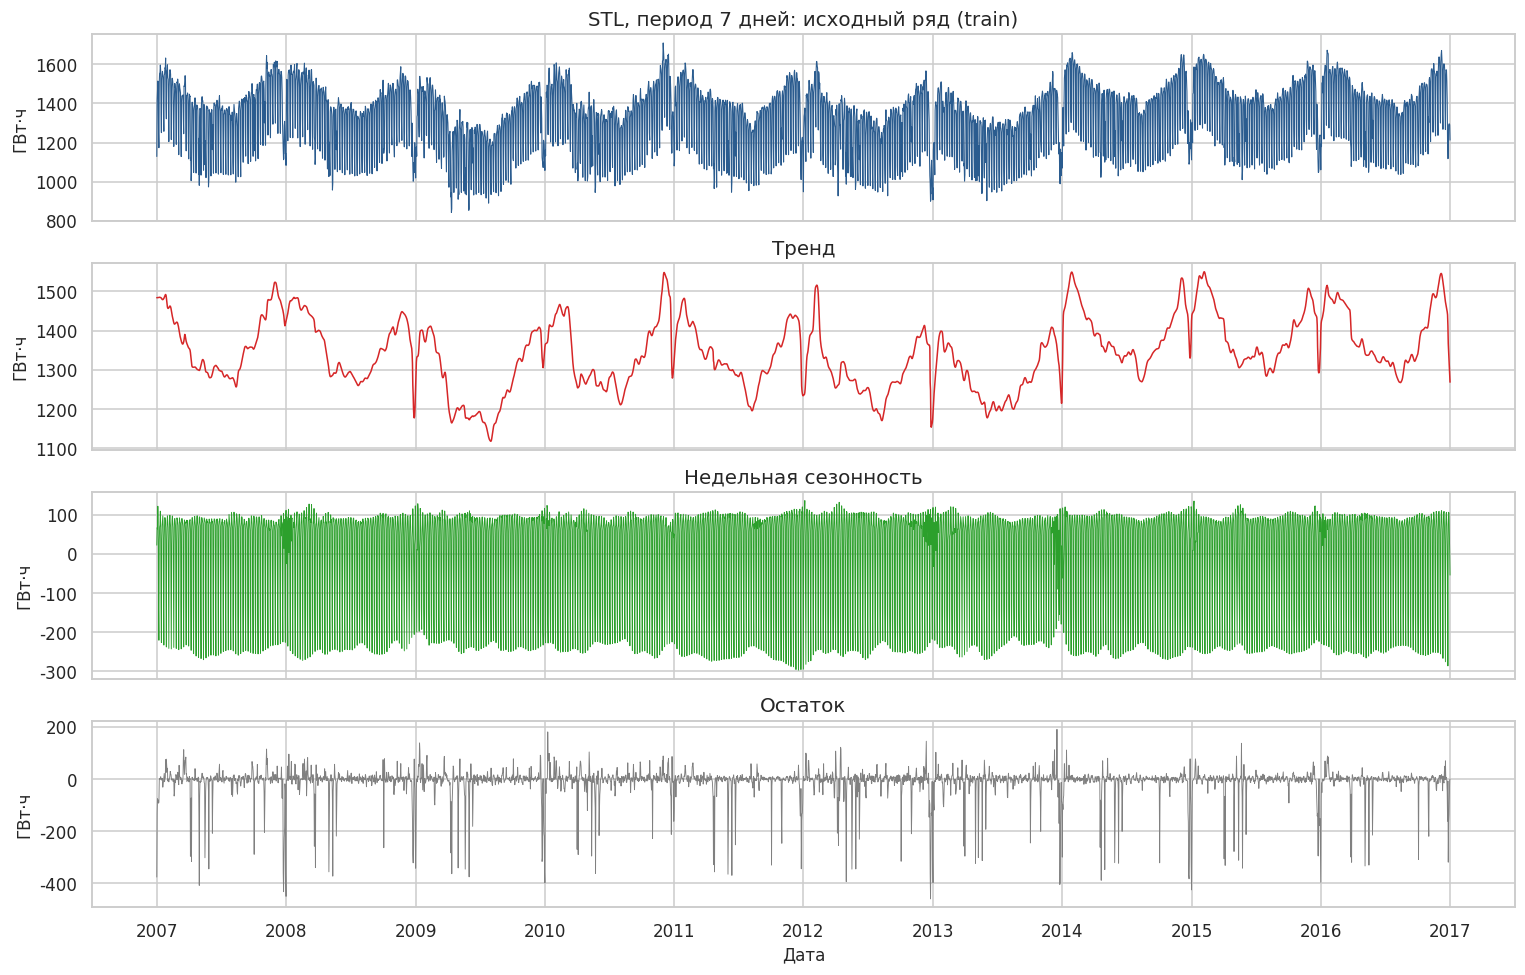

СКО недельной сезонности: 128.8 ГВт·ч
СКО тренда: 88.8 ГВт·ч
СКО остатка: 60.4 ГВт·ч


In [14]:
stl_week = STL(train["y"].asfreq("D"), period=7, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
axes[0].plot(train.index, train["y"], color="#2b5c8f", linewidth=0.7)
axes[0].set_title("STL, период 7 дней: исходный ряд (train)")
axes[1].plot(train.index, stl_week.trend, color="#d62728", linewidth=1)
axes[1].set_title("Тренд")
axes[2].plot(train.index, stl_week.seasonal, color="#2ca02c", linewidth=0.6)
axes[2].set_title("Недельная сезонность")
axes[3].plot(train.index, stl_week.resid, color="gray", linewidth=0.6)
axes[3].set_title("Остаток")
for ax in axes:
    ax.set_ylabel("ГВт·ч")
axes[-1].set_xlabel("Дата")
plt.tight_layout()
plt.show()

print(f"СКО недельной сезонности: {stl_week.seasonal.std():.1f} ГВт·ч")
print(f"СКО тренда: {stl_week.trend.std():.1f} ГВт·ч")
print(f"СКО остатка: {stl_week.resid.std():.1f} ГВт·ч")


### STL с недельным периодом

Недельная сезонность выделяется стабильной пилой будни/выходные амплитудой порядка сотни ГВт·ч. Тренд медленно колеблется, без крутого наклона. В остатке остаются праздники и годовая сезонность — недельный период их не забирает. Значит, одной недельной STL-компоненты для прогноза мало.


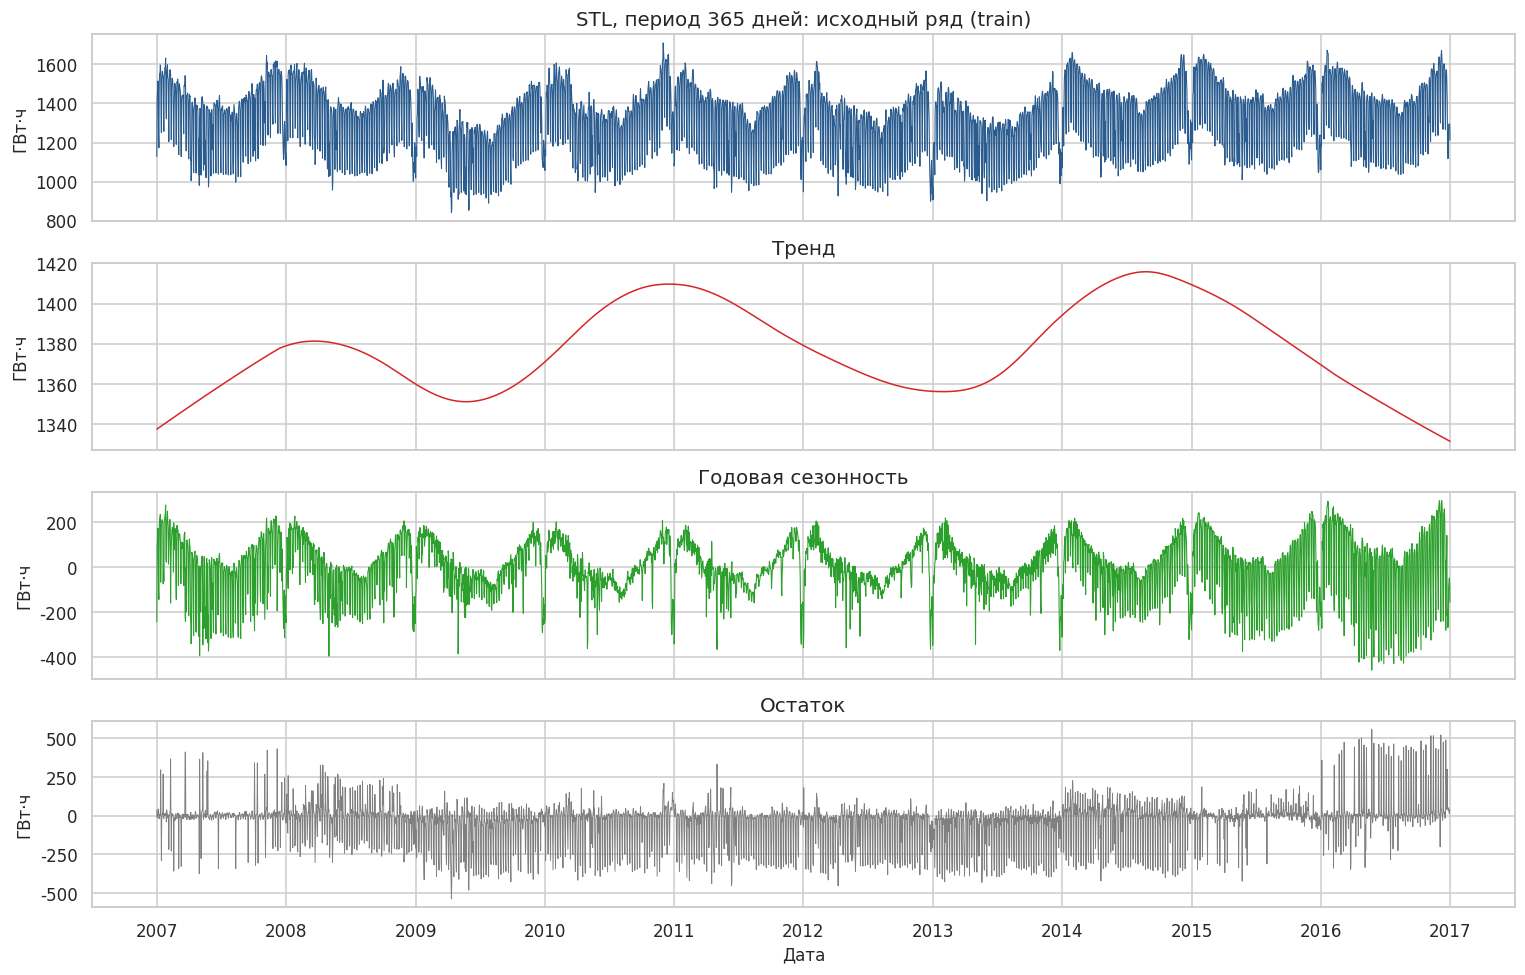

СКО годовой сезонности: 126.7 ГВт·ч
СКО тренда: 21.7 ГВт·ч
СКО остатка: 135.6 ГВт·ч


In [15]:
stl_year = STL(train["y"].asfreq("D"), period=365, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
axes[0].plot(train.index, train["y"], color="#2b5c8f", linewidth=0.7)
axes[0].set_title("STL, период 365 дней: исходный ряд (train)")
axes[1].plot(train.index, stl_year.trend, color="#d62728", linewidth=1)
axes[1].set_title("Тренд")
axes[2].plot(train.index, stl_year.seasonal, color="#2ca02c", linewidth=0.7)
axes[2].set_title("Годовая сезонность")
axes[3].plot(train.index, stl_year.resid, color="gray", linewidth=0.6)
axes[3].set_title("Остаток")
for ax in axes:
    ax.set_ylabel("ГВт·ч")
axes[-1].set_xlabel("Дата")
plt.tight_layout()
plt.show()

print(f"СКО годовой сезонности: {stl_year.seasonal.std():.1f} ГВт·ч")
print(f"СКО тренда: {stl_year.trend.std():.1f} ГВт·ч")
print(f"СКО остатка: {stl_year.resid.std():.1f} ГВт·ч")


### STL с годовым периодом

Годовая компонента забирает зимний максимум и летний минимум. Остаток после неё всё ещё содержит недельную пилу и праздники. Тренд почти плоский (СКО заметно меньше сезонной волны). Вывод: ряд аддитивно складывается из слабого тренда, сильной недели и умеренного года — это как раз то, что кодируют лаг 7, выходной и месяц.


In [16]:
week_pattern = pd.Series(stl_week.seasonal.values, index=train.index).groupby(train.index.dayofweek).mean()
year_pattern = pd.Series(stl_year.seasonal.values, index=train.index).groupby(train.index.dayofyear).mean()

feat_stl = feat.copy()
feat_stl["STL неделя"] = feat_stl.index.dayofweek.map(week_pattern)
feat_stl["STL год"] = feat_stl.index.dayofyear.map(year_pattern)
# тренд известен только до конца train; на тесте — последнее значение (без заглядывания вперёд)
trend_lag = stl_year.trend.shift(1)
last_trend = stl_year.trend.dropna().iloc[-1]
feat_stl["STL тренд лаг 1"] = trend_lag.reindex(feat_stl.index).fillna(last_trend)

train_stl = feat_stl.loc[:"2016-12-31"].dropna()
test_stl = feat_stl.loc["2017-01-01":]
X_stl = [c for c in train_stl.columns if c != "y"]

pipe_stl = Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=10))])
pipe_stl.fit(train_stl[X_stl], train_stl["y"])
pred_stl = pipe_stl.predict(test_stl[X_stl])

cmp = pd.concat([
    metrics_table(test["y"], pred_test, "Без STL-признаков"),
    metrics_table(test_stl["y"], pred_stl, "С STL-признаками train"),
], axis=1).T
print("Одношаговый тест: эффект признаков из STL (компоненты считались только на train):")
print(cmp.round(3).to_string())
print("\nШаблон недельной STL-сезонности по дням недели:")
print(pd.Series(week_pattern.values, index=["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]).round(1).to_string())


Одношаговый тест: эффект признаков из STL (компоненты считались только на train):
                             MSE     MAE  MAPE, %  WAPE, %
Без STL-признаков       2199.737  27.354    2.094    1.978
С STL-признаками train  2261.160  29.270    2.201    2.117

Шаблон недельной STL-сезонности по дням недели:
Пн     60.7
Вт     88.5
Ср     91.5
Чт     90.1
Пт     62.5
Сб   -146.7
Вс   -246.7


### Улучшают ли STL-признаки прогноз?

Нет: MAE на тесте растёт с 27,35 до 29,27 ГВт·ч. Календарь, лаг 7 и скользящее среднее уже несут ту же информацию, что недельный и годовой шаблоны STL (выходные в STL: суббота −147, воскресенье −247 ГВт·ч). Добавление компонент, оценённых только на train, даёт почти линейно зависимые столбцы. STL полезна как **диагностика**, но не как обязательный источник новых регрессоров, если сезонные лаги уже есть.


### Сводная таблица метрик

| Схема | MSE | MAE, ГВт·ч | MAPE, % | WAPE, % |
| --- | ---: | ---: | ---: | ---: |
| Ridge, train, 1 шаг | 2115,6 | 28,05 | 2,21 | 2,10 |
| Ridge, test, 1 шаг | 2199,7 | 27,35 | 2,09 | 1,98 |
| Наивный лаг 7, test | 9350,8 | 54,10 | 4,04 | 3,91 |
| Наивный лаг 1, test | 22248,0 | 102,34 | 7,73 | 7,40 |
| Наивный лаг 365, test | 23011,9 | 105,05 | 7,88 | 7,60 |
| Рекурсия \(H=14\), 1 января 2017 | 88887,9 | 295,77 | 19,95 | 19,78 |
| Рекурсия \(H=14\), все старты 2017 | 6609,9 | 50,24 | 3,68 | 3,63 |
| Ridge + STL-признаки, test, 1 шаг | 2261,2 | 29,27 | 2,20 | 2,12 |

Одношаговая Ridge устойчиво лучше наивных баз (MAE 27 против 54 у лага 7). Многошаговая рекурсия в среднем теряет примерно двукратный запас по MAE; на новогоднем старте запас пропадает полностью.


### 5) Заключение

Суточное потребление электроэнергии в Германии — ряд со **слабым трендом**, сильной **недельной** и умеренной **годовой** сезонностью и календарными провалами на праздниках. Сведение к регрессии с признаками только из прошлого работает: Ridge на лагах, окнах и календаре даёт одношаговый тест с MAPE около **2%** и не расходится с обучением.

Рекурсивный прогноз на 14 суток заметно слабее: ошибка на празднике попадает в следующие лаги и размазывает траекторию. STL подтверждает структуру ряда, но признаки из компонент декомпозиции качество не улучшают — они дублируют уже построенные сезонные лаги.

**Ограничения модели.** Линейная регрессия не описывает растянутые каникулы и «мосты» между праздником и выходным. Нет суточного профиля (данные дневные). Ветер и солнце не использованы. Горизонт \(H>1\) здесь — слабое место одношаговой модели; для него логичнее прямые модели на каждый шаг или отдельный сезонный метод. Зато для прогноза на завтра пайплайн «календарь + лаги + Ridge + TimeSeriesSplit» достаточен и не допускает утечки из будущего.


### Источники

1. Open Power System Data. Time series: daily electricity consumption in Germany, 2006–2017. https://data.open-power-system-data.org/
2. Kaggle: Electricity Consumption. https://www.kaggle.com/datasets/arashnic/electricity-consumption
3. Hyndman R. J., Athanasopoulos G. *Forecasting: Principles and Practice*. Главы о лагах, кросс-валидации рядов и многошаговых стратегиях.
4. Cleveland R. B. et al. STL: A Seasonal-Trend Decomposition Procedure Based on Loess. *Journal of Official Statistics*, 1990.
5. Документация scikit-learn: `TimeSeriesSplit`, `Ridge`. Документация statsmodels: `STL`.
